In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f9f9f9',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
    'axes.titlesize': 14,
    'axes.titleweight': 'bold'
})

path = r'C:\Users\ROOT\Desktop\churn-analysis\data\cleaned\\'
master = pd.read_csv(path + 'master_table.csv', parse_dates=['order_purchase_timestamp'])
rfm    = pd.read_csv(path + 'rfm_table.csv')

print("master:", master.shape)
print("rfm   :", rfm.shape)

master: (99992, 21)
rfm   : (96096, 8)


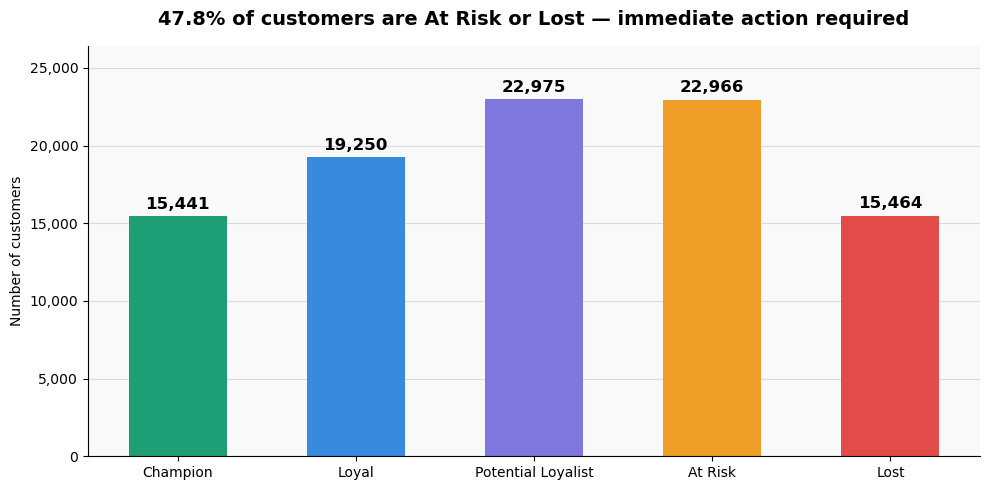

✅ Chart 1 saved


In [3]:
seg_order = ['Champion','Loyal','Potential Loyalist','At Risk','Lost']
seg_colors = ['#1D9E75','#378ADD','#7F77DD','#EF9F27','#E24B4A']
seg_counts = rfm['Segment'].value_counts().reindex(seg_order)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(seg_counts.index, seg_counts.values, color=seg_colors, width=0.55, zorder=2)

for bar, val in zip(bars, seg_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{val:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('47.8% of customers are At Risk or Lost — immediate action required', pad=15)
ax.set_ylabel('Number of customers')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', alpha=0.4, zorder=1)
ax.set_ylim(0, seg_counts.max() * 1.15)

plt.tight_layout()
plt.savefig(r'C:\Users\ROOT\Desktop\churn-analysis\outputs\charts\01_rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 1 saved")

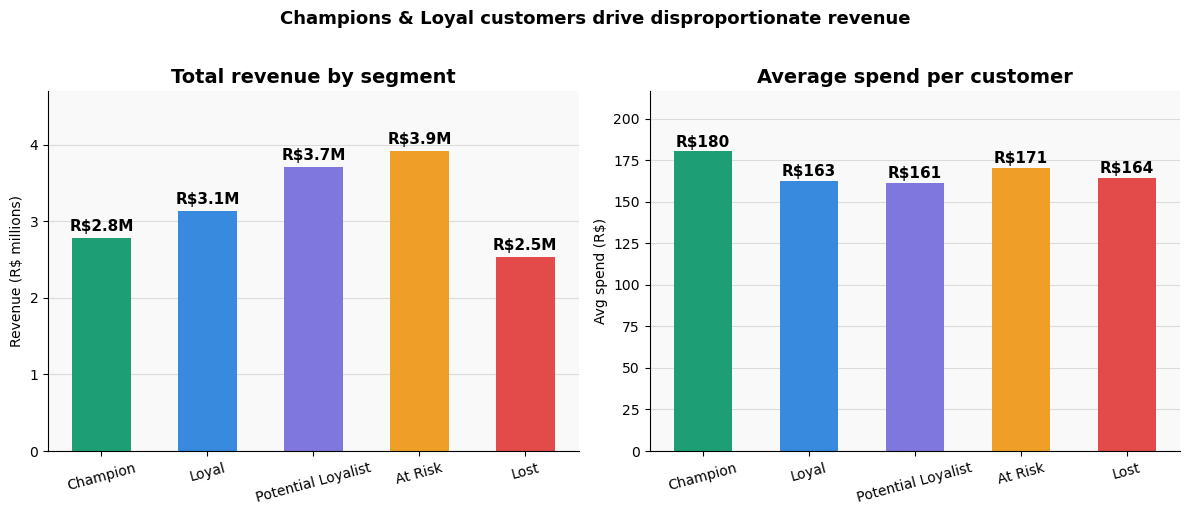

✅ Chart 2 saved


In [5]:
seg_revenue = rfm.groupby('Segment')['Monetary'].agg(['sum','mean']).reindex(seg_order)
seg_revenue['sum_M'] = seg_revenue['sum'] / 1e6  # in millions

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Total revenue by segment
bars = ax1.bar(seg_revenue.index, seg_revenue['sum_M'], color=seg_colors, width=0.55, zorder=2)
for bar, val in zip(bars, seg_revenue['sum_M']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'R${val:.1f}M', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.set_title('Total revenue by segment')
ax1.set_ylabel('Revenue (R$ millions)')
ax1.grid(axis='y', alpha=0.4, zorder=1)
ax1.set_ylim(0, seg_revenue['sum_M'].max() * 1.2)
ax1.tick_params(axis='x', rotation=15)

# Avg order value by segment
bars2 = ax2.bar(seg_revenue.index, seg_revenue['mean'], color=seg_colors, width=0.55, zorder=2)
for bar, val in zip(bars2, seg_revenue['mean']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'R${val:.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.set_title('Average spend per customer')
ax2.set_ylabel('Avg spend (R$)')
ax2.grid(axis='y', alpha=0.4, zorder=1)
ax2.set_ylim(0, seg_revenue['mean'].max() * 1.2)
ax2.tick_params(axis='x', rotation=15)

plt.suptitle('Champions & Loyal customers drive disproportionate revenue', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(r'C:\Users\ROOT\Desktop\churn-analysis\outputs\charts\02_revenue_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 2 saved")

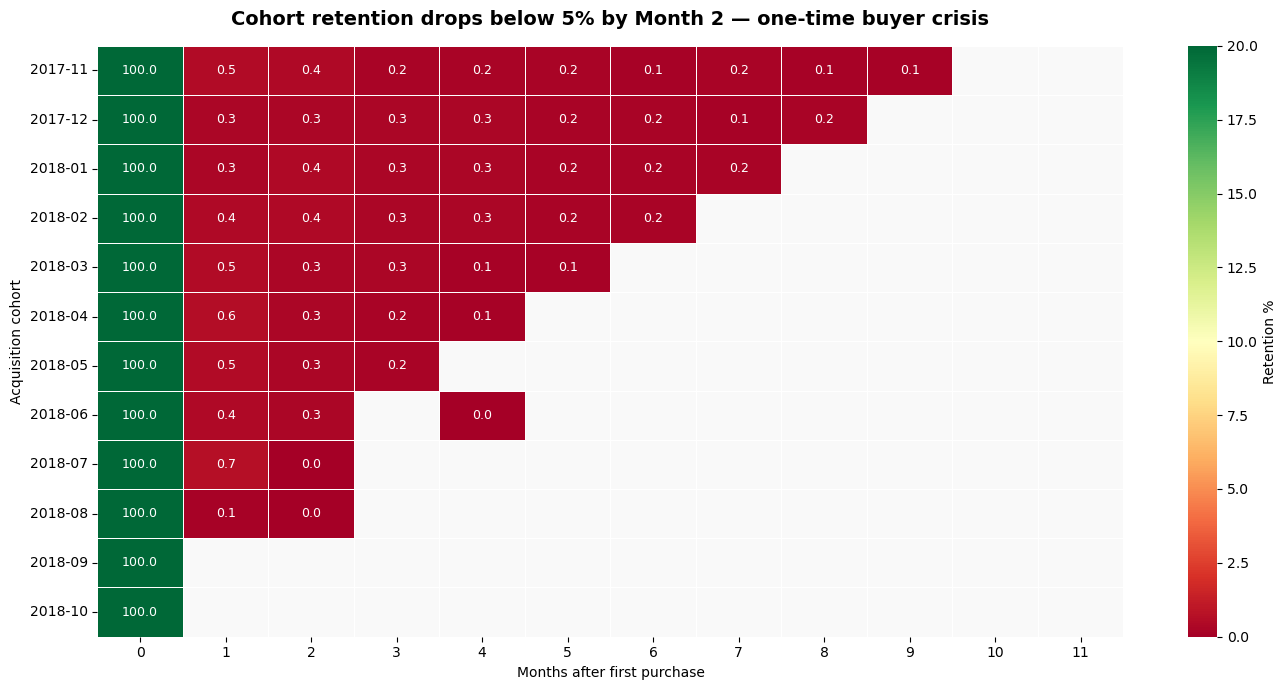

✅ Chart 3 saved


In [7]:
master['cohort_month'] = (master.groupby('customer_unique_id')['order_purchase_timestamp']
                          .transform('min').dt.to_period('M'))
master['order_month']  = master['order_purchase_timestamp'].dt.to_period('M')
master['cohort_index'] = (master['order_month'] - master['cohort_month']).apply(lambda x: x.n)

cohort_data = (master.groupby(['cohort_month','cohort_index'])['customer_unique_id']
               .nunique().unstack())
retention   = (cohort_data.divide(cohort_data.iloc[:,0], axis=0) * 100).round(1)

# Keeping first 12 months, last 12 cohorts for readability
retention_plot = retention.iloc[-12:, :12]

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(retention_plot,
            annot=True, fmt='.1f', linewidths=0.5,
            cmap='RdYlGn', vmin=0, vmax=20,
            annot_kws={'size': 9}, ax=ax,
            cbar_kws={'label': 'Retention %'})

ax.set_title('Cohort retention drops below 5% by Month 2 — one-time buyer crisis', pad=15)
ax.set_xlabel('Months after first purchase')
ax.set_ylabel('Acquisition cohort')

plt.tight_layout()
plt.savefig(r'C:\Users\ROOT\Desktop\churn-analysis\outputs\charts\03_cohort_retention.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 3 saved")

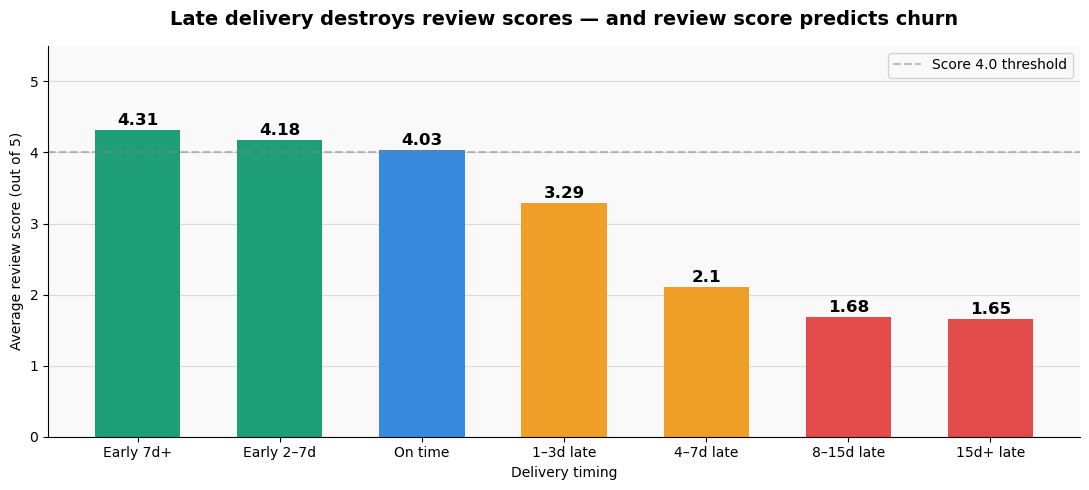

✅ Chart 4 saved


In [9]:
delay_bins = pd.cut(master['delivery_delay_days'].dropna(),
                    bins=[-30,-7,-1,0,3,7,15,60],
                    labels=['Early 7d+','Early 2–7d','On time','1–3d late',
                            '4–7d late','8–15d late','15d+ late'])

delay_review = (master.assign(delay_bin=delay_bins)
                .groupby('delay_bin', observed=True)['review_score']
                .mean().round(2))

colors_dr = ['#1D9E75','#1D9E75','#378ADD','#EF9F27','#EF9F27','#E24B4A','#E24B4A']

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(delay_review.index, delay_review.values, color=colors_dr, width=0.6, zorder=2)
for bar, val in zip(bars, delay_review.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'{val}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.axhline(y=4.0, color='gray', linestyle='--', alpha=0.5, label='Score 4.0 threshold')
ax.set_title('Late delivery destroys review scores — and review score predicts churn', pad=15)
ax.set_ylabel('Average review score (out of 5)')
ax.set_xlabel('Delivery timing')
ax.set_ylim(0, 5.5)
ax.grid(axis='y', alpha=0.4, zorder=1)
ax.legend()

plt.tight_layout()
plt.savefig(r'C:\Users\ROOT\Desktop\churn-analysis\outputs\charts\04_delay_vs_review.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 4 saved")

In [11]:
# Revenue at Risk calculation — Executive headline KPI
at_risk_rev  = rfm[rfm['Segment'] == 'At Risk']['Monetary'].sum()
lost_rev     = rfm[rfm['Segment'] == 'Lost']['Monetary'].sum()
total_rev    = rfm['Monetary'].sum()
risk_pct     = (at_risk_rev + lost_rev) / total_rev * 100

print("=" * 45)
print("      EXECUTIVE SUMMARY — KEY METRICS")
print("=" * 45)
print(f"  Total platform revenue   : R$ {total_rev:>10,.0f}")
print(f"  At Risk segment revenue  : R$ {at_risk_rev:>10,.0f}")
print(f"  Lost segment revenue     : R$ {lost_rev:>10,.0f}")
print(f"  Total revenue at risk    : R$ {at_risk_rev+lost_rev:>10,.0f}")
print(f"  % of revenue at risk     :    {risk_pct:>9.1f}%")
print("=" * 45)
print(f"\n  Potential Loyalists      :    {22975:>9,} customers")
print(f"  Est. recoverable revenue : R$ {22975 * 161:>10,.0f}")
print("  (if converted to Loyal @ avg R$161 spend)")
print("=" * 45)

      EXECUTIVE SUMMARY — KEY METRICS
  Total platform revenue   : R$ 16,081,421
  At Risk segment revenue  : R$  3,915,909
  Lost segment revenue     : R$  2,539,518
  Total revenue at risk    : R$  6,455,428
  % of revenue at risk     :         40.1%

  Potential Loyalists      :       22,975 customers
  Est. recoverable revenue : R$  3,698,975
  (if converted to Loyal @ avg R$161 spend)
